In [5]:
!pip install GEOparse xgboost shap gseapy seaborn

In [6]:
import GEOparse
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import shap

import warnings
warnings.filterwarnings("ignore")

In [7]:
gse = GEOparse.get_GEO(
    geo="GSE45827",
    destdir="./"
)

print(gse)

03-Aug-2026 06:34:46 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
03-Aug-2026 06:34:46 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
03-Aug-2026 06:34:46 INFO GEOparse - Parsing ./GSE45827_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE45827_family.soft.gz: 
03-Aug-2026 06:34:46 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
03-Aug-2026 06:34:46 DEBUG GEOparse - SERIES: GSE45827
DEBUG:GEOparse:SERIES: GSE45827
03-Aug-2026 06:34:46 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
03-Aug-2026 06:34:49 DEBUG GEOparse - SAMPLE: GSM1116084
DEBUG:GEOparse:SAMPLE: GSM1116084
03-Aug-2026 06:34:49 DEBUG GEOparse - SAMPLE: GSM1116085
DEBUG:GEOparse:SAMPLE: GSM1116085
03-Aug-2026 06:34:50 DEBUG GEOparse - SAMPLE: GSM1116086
DEBUG:GEOparse:SAMPLE: GSM1116086
03-Aug-2026 06:34:50 DEBUG GEOparse - SAMPLE: GSM1116087
DEBUG:GEOparse:SAMPLE

<SERIES: GSE45827 - 155 SAMPLES, 1 d(s)>


In [8]:
#expression-matrix
X = gse.pivot_samples("VALUE").T

print(X.shape)

(155, 29873)


In [9]:
#metadata
meta = gse.phenotype_data

print(meta.columns)

meta.head()

Index(['title', 'geo_accession', 'status', 'submission_date',
       'last_update_date', 'type', 'channel_count', 'source_name_ch1',
       'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.diagnosis',
       'characteristics_ch1.1.tumor subtype', 'characteristics_ch1.2.batch',
       'characteristics_ch1.3.hybridation', 'molecule_ch1',
       'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1',
       'hyb_protocol', 'scan_protocol', 'data_processing', 'platform_id',
       'contact_name', 'contact_email', 'contact_phone', 'contact_fax',
       'contact_laboratory', 'contact_department', 'contact_institute',
       'contact_address', 'contact_city', 'contact_zip/postal_code',
       'contact_country', 'supplementary_file', 'series_id', 'data_row_count',
       'characteristics_ch1.0.cell line', 'characteristics_ch1.1.cell origin'],
      dtype='object')


,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,taxid_ch1,...,contact_institute,contact_address,contact_city,contact_zip/postal_code,contact_country,supplementary_file,series_id,data_row_count,characteristics_ch1.0.cell line,characteristics_ch1.1.cell origin
GSM1116084,Basal Sample1 rep1,GSM1116084,Public on Mar 24 2016,Apr 05 2013,Mar 24 2016,RNA,1,Human Basal Tumor Sample,Homo sapiens,9606,...,Institut Curie,26 rue d'Ulm,PARIS,75248,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1116...,GSE45827,29873,NaN,NaN
GSM1116085,Basal Sample2 rep1-2,GSM1116085,Public on Mar 24 2016,Apr 05 2013,Mar 24 2016,RNA,1,Human Basal Tumor Sample,Homo sapiens,9606,...,Institut Curie,26 rue d'Ulm,PARIS,75248,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1116...,GSE45827,29873,NaN,NaN
GSM1116086,Her2 Sample3 rep1,GSM1116086,Public on Mar 24 2016,Apr 05 2013,Mar 24 2016,RNA,1,Human Her2 Tumor Sample,Homo sapiens,9606,...,Institut Curie,26 rue d'Ulm,PARIS,75248,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1116...,GSE45827,29873,NaN,NaN
GSM1116087,Basal Sample4 rep1-2,GSM1116087,Public on Mar 24 2016,Apr 05 2013,Mar 24 2016,RNA,1,Human Basal Tumor Sample,Homo sapiens,9606,...,Institut Curie,26 rue d'Ulm,PARIS,75248,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1116...,GSE45827,29873,NaN,NaN
GSM1116088,Her2 Sample5 rep1-2,GSM1116088,Public on Mar 24 2016,Apr 05 2013,Mar 24 2016,RNA,1,Human Her2 Tumor Sample,Homo sapiens,9606,...,Institut Curie,26 rue d'Ulm,PARIS,75248,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1116...,GSE45827,29873,NaN,NaN


In [10]:
#extract subtypes
for col in meta.columns:
    if "characteristics" in col.lower():
        print(col)
        print(meta[col].unique()[:20])
        print("="*50)

characteristics_ch1.0.diagnosis
['Breast cancer' nan 'None (normal)']
characteristics_ch1.1.tumor subtype
['Basal' 'Her2' nan 'N/A' 'Luminal A' 'Luminal B']
characteristics_ch1.2.batch
['8' '9' '10' '2' '5' '1' '4' '3']
characteristics_ch1.3.hybridation
['-1' '2' '1' '3']
characteristics_ch1.0.cell line
[nan 'BT20' 'HCC70' 'HCC1143' 'HCC1187' 'HCC1937' 'MDA-MB-468' 'HCC38'
 'MDA-MB-231' 'MDA-MB-436' 'MDA-MB-157' 'BT-549' 'Hs 578T' 'MCF-12A'
 '184B5']
characteristics_ch1.1.cell origin
[nan 'Breast carcinoma' 'Breast mammary gland']


In [11]:
#only tumor
subtype_col = "characteristics_ch1.1.tumor subtype"

subtypes = meta[subtype_col].astype(str)

mask = subtypes.isin([
    "Basal",
    "Her2",
    "Luminal A",
    "Luminal B"
])

X = X.loc[mask]
y = subtypes[mask]

print(y.value_counts())
print("\nTotal samples:", len(y))

characteristics_ch1.1.tumor subtype
Basal        41
Her2         30
Luminal B    30
Luminal A    29
Name: count, dtype: int64

Total samples: 130


In [12]:
#encode labels
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['Basal' 'Her2' 'Luminal A' 'Luminal B']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [14]:
import numpy as np
import random
import os

# ── FIX SEED BEFORE FIT ──────────────────────────────────
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)  # <- this fixes mutual_info_classif

#feature selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=300
)
X_train = selector.fit_transform(
    X_train,
    y_train
)

X_test = selector.transform(X_test)

print(X_train.shape)

(104, 300)


In [15]:
#scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [16]:
#model
model = XGBClassifier(
    objective="multi:softprob",
    num_class=4,

    n_estimators=100,

    max_depth=6,

    learning_rate=0.3,

    subsample=1.0,

    colsample_bytree=1.0,

    random_state=42,

    eval_metric="mlogloss"
)
model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, num_class=4, ...)

In [17]:
#prediction
y_pred = model.predict(X_test)

acc = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy = {acc:.4f}"
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

Accuracy = 0.9615
              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00         8
        Her2       1.00      1.00      1.00         6
   Luminal A       0.86      1.00      0.92         6
   Luminal B       1.00      0.83      0.91         6

    accuracy                           0.96        26
   macro avg       0.96      0.96      0.96        26
weighted avg       0.97      0.96      0.96        26



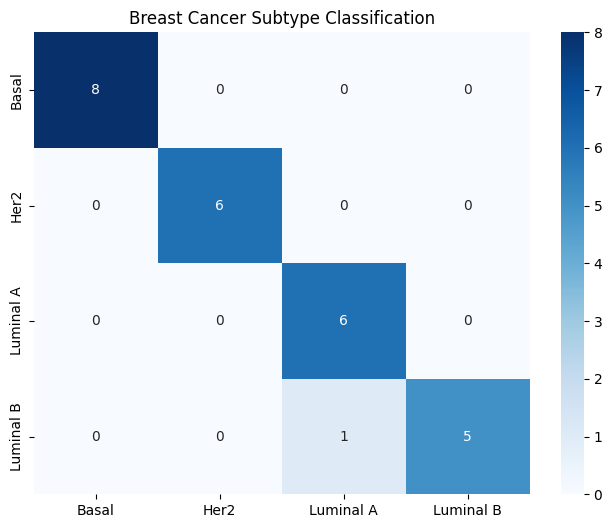

In [18]:
#confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title(
    "Breast Cancer Subtype Classification"
)
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [19]:
import numpy as np
import random
import os

# 1. Python + Numpy + Hash seed
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)  # <- this line fixes mutual_info_classif

# CORRECT — use Pipeline so selector fits only on training folds
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("selector", SelectKBest(mutual_info_classif, k=300)),
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.3,
                            eval_metric="mlogloss", random_state=42)) # <- fixes XGB
])

# 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # <- fixes CV splits

scores = cross_val_score(
    pipeline, X, y_encoded,
    cv=cv, scoring="accuracy"
)

print("CV Accuracy:", scores)
print(f"Mean: {scores.mean():.4f} ± {scores.std():.4f}")

CV Accuracy: [0.84615385 0.92307692 0.96153846 0.92307692 1.        ]
Mean: 0.9308 ± 0.0510


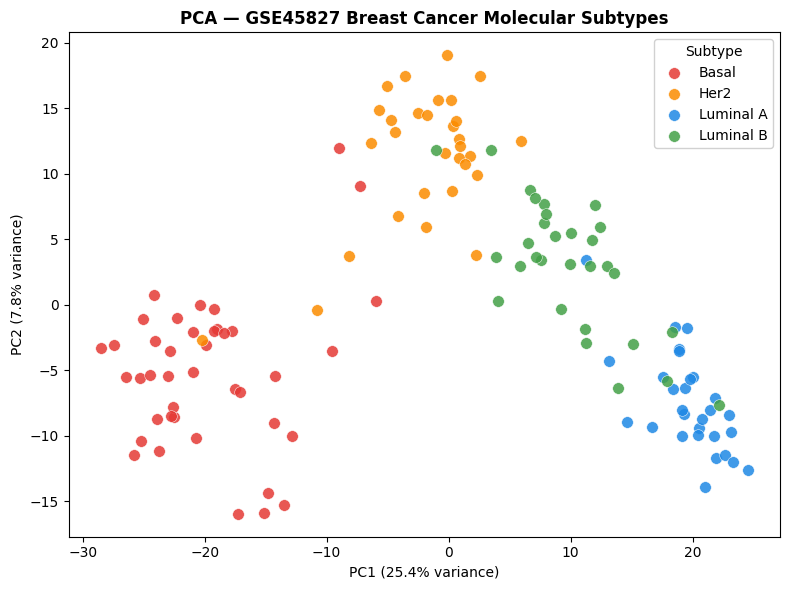

In [20]:
#pca plot
from sklearn.decomposition import PCA

# Use top 1000 most variable genes on full dataset
var_genes_idx = X.var(axis=0).nlargest(1000).index
X_pca_input = X[var_genes_idx]

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(StandardScaler().fit_transform(X_pca_input))

pc_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
pc_df["Subtype"] = y.values

palette = {
    "Basal":     "#E53935",
    "Her2":      "#FB8C00",
    "Luminal A": "#1E88E5",
    "Luminal B": "#43A047"
}

plt.figure(figsize=(8, 6))
for subtype, grp in pc_df.groupby("Subtype"):
    plt.scatter(grp["PC1"], grp["PC2"],
                label=subtype, s=70, alpha=0.85,
                color=palette[subtype], edgecolors="white", linewidths=0.4)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA — GSE45827 Breast Cancer Molecular Subtypes", fontweight="bold")
plt.legend(title="Subtype", framealpha=0.9)
plt.tight_layout()
plt.savefig("PCA_subtypes.png", dpi=300)
plt.show()

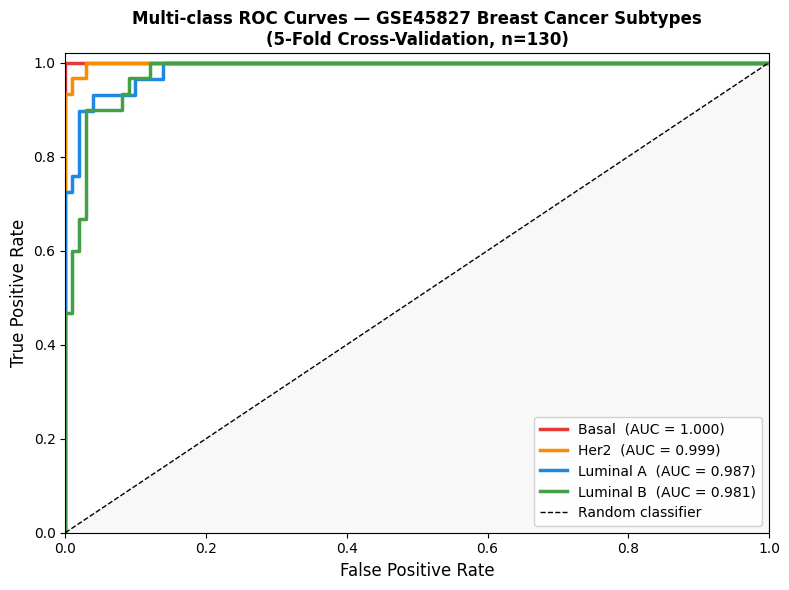

In [21]:
import numpy as np
import random
import os
import matplotlib.pyplot as plt

# ── FIX ALL SEEDS FOR REPRODUCIBILITY ──────────────────────────
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)  # <- this fixes mutual_info_classif

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Get out-of-fold probability predictions (honest evaluation)
pipeline = Pipeline([
    ("selector", SelectKBest(mutual_info_classif, k=300)),  # now reproducible
    ("scaler",   StandardScaler()),
    ("model",    XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.3,
        eval_metric="mlogloss",
        random_state=42,
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # fixes CV splits

# This gives probabilities for ALL 130 samples without leakage
y_prob_cv = cross_val_predict(
    pipeline, X, y_encoded,
    cv=cv,
    method="predict_proba",   # ← key: gets probabilities not labels
)

# Binarize labels for one-vs-rest ROC
y_bin = label_binarize(y_encoded, classes=[0, 1, 2, 3])

# ── Plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors    = ["#E53935", "#FB8C00", "#1E88E5", "#43A047"]
subtypes  = encoder.classes_   # ['Basal', 'Her2', 'Luminal A', 'Luminal B']

for i, (cls, col) in enumerate(zip(subtypes, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_cv[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=2.5,
            label=f"{cls}  (AUC = {roc_auc:.3f})")

ax.plot([0,1],[0,1], "k--", lw=1, label="Random classifier")
ax.fill_between([0,1],[0,1], alpha=0.05, color="grey")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Multi-class ROC Curves — GSE45827 Breast Cancer Subtypes\n"
             "(5-Fold Cross-Validation, n=130)", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", framealpha=0.9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("ROC_CV_curves.png", dpi=300)
plt.show()